In [1]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

In [2]:
def plot_metrics(paths, keys=["train/loss"], align_steps=False):
    if not isinstance(paths, dict):
        paths = {"0": paths}

    eas = {}
    for name, path in paths.items():
        ea = event_accumulator.EventAccumulator(path)
        ea.Reload()
        eas[name] = ea

    n = len(keys)
    cols = 2
    rows = (n + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    step_coefs = {}
    if align_steps:
        for name, ea in eas.items():
            scalars = ea.Scalars("train/loss")
            steps = [x.step for x in scalars]
            step_coefs[name] = max(steps)
        for name in step_coefs:
            step_coefs[name] = max(step_coefs.values()) / step_coefs[name]
        print(step_coefs)

    for i, key in enumerate(keys):
        for name, ea in eas.items():
            try:
                scalars = ea.Scalars(key)
                steps = [x.step * step_coefs.get(name, 1.) for x in scalars]
                values = [x.value for x in scalars]

                axes[i].plot(steps, values, label=f"{name}[{key}]")
                axes[i].set_xlabel('Step')
                axes[i].set_ylabel('Value')
                axes[i].set_title(key)
                axes[i].legend()
                axes[i].grid(True)
            except Exception:
                pass

    # Скрываем лишние ячейки, если ключей нечётное количество
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

{'Baseline-16': 3.9962914020205464, 'Baseline-128': 3.9962914020205464, 'V2': 3.9962914020205464, 'V3': 1.0}


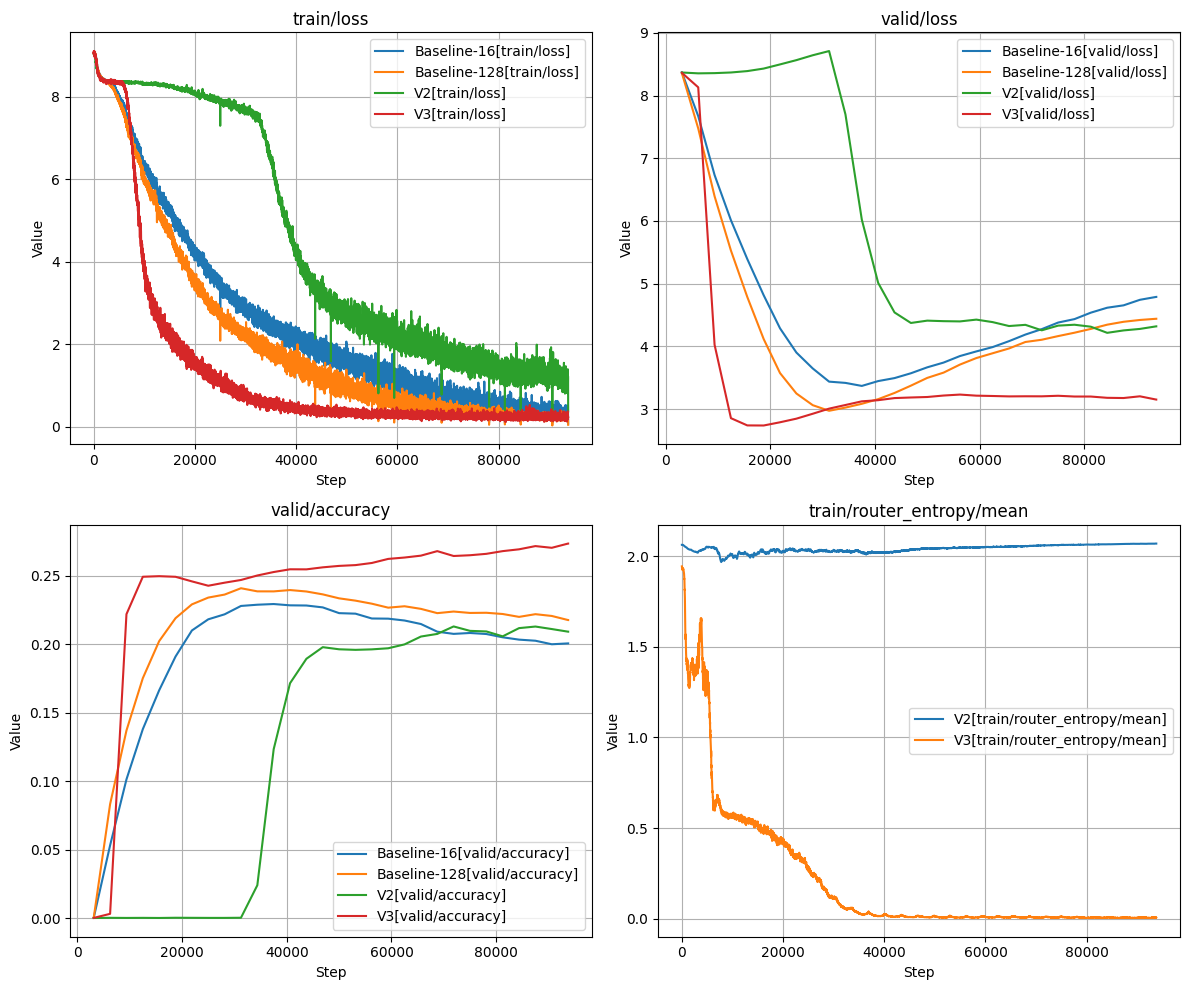

In [5]:
plot_metrics(
    # {
    #     "Mamba32": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777909991.butch.38525.0",
    #     "Mamba64": "/home/needpetrov/projects/zoology/runs/Mamba_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777915111.butch.65246.0",
    #     "Attn32": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_32/default/events.out.tfevents.1777915105.butch.65084.0",
    #     "Attn64": "/home/needpetrov/projects/zoology/runs/MHA_h4_2_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777909986.butch.38386.0",
    # },
    {
        "Baseline-16": "/home/needpetrov/projects/zoology/runs/S4D_256_D16_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778139040.butch.1657192.2",
        "Baseline-128": "/home/needpetrov/projects/zoology/runs/S4D_256_D128_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778133242.butch.1657192.0",
        "V2": "/home/needpetrov/projects/zoology/runs/Due_S4D_8_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778102570.butch.1610633.0",
        "V3": "/home/needpetrov/projects/zoology/runs/Tre_MoE_S4D_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778130978.butch.1645958.0",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=True,
)

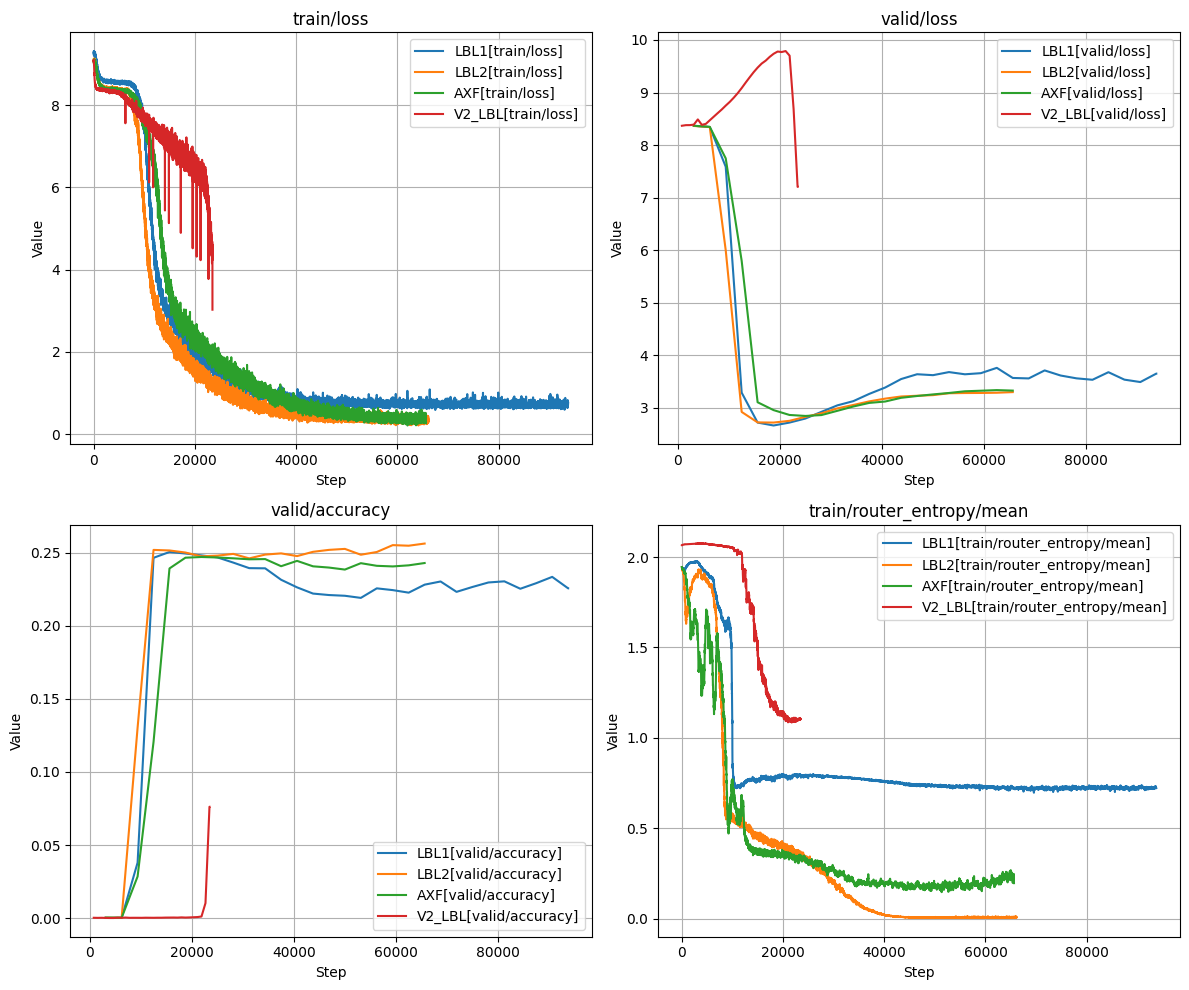

In [4]:
plot_metrics(
    {
        "LBL1": "/home/needpetrov/projects/zoology/runs/TreLBL_MoE_S4D_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778180185.butch.1933353.0",
        "LBL2": "/home/needpetrov/projects/zoology/runs/TreLBL_MoE_S4D_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778165393.butch.1844817.0",
        "AXF": "/home/needpetrov/projects/zoology/runs/TreAXF_MoE_S4D_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778165518.butch.1846013.0",
        "V2_LBL": "/home/needpetrov/projects/zoology/runs/DueLBL_S4D_8_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778182280.butch.923205.0"
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

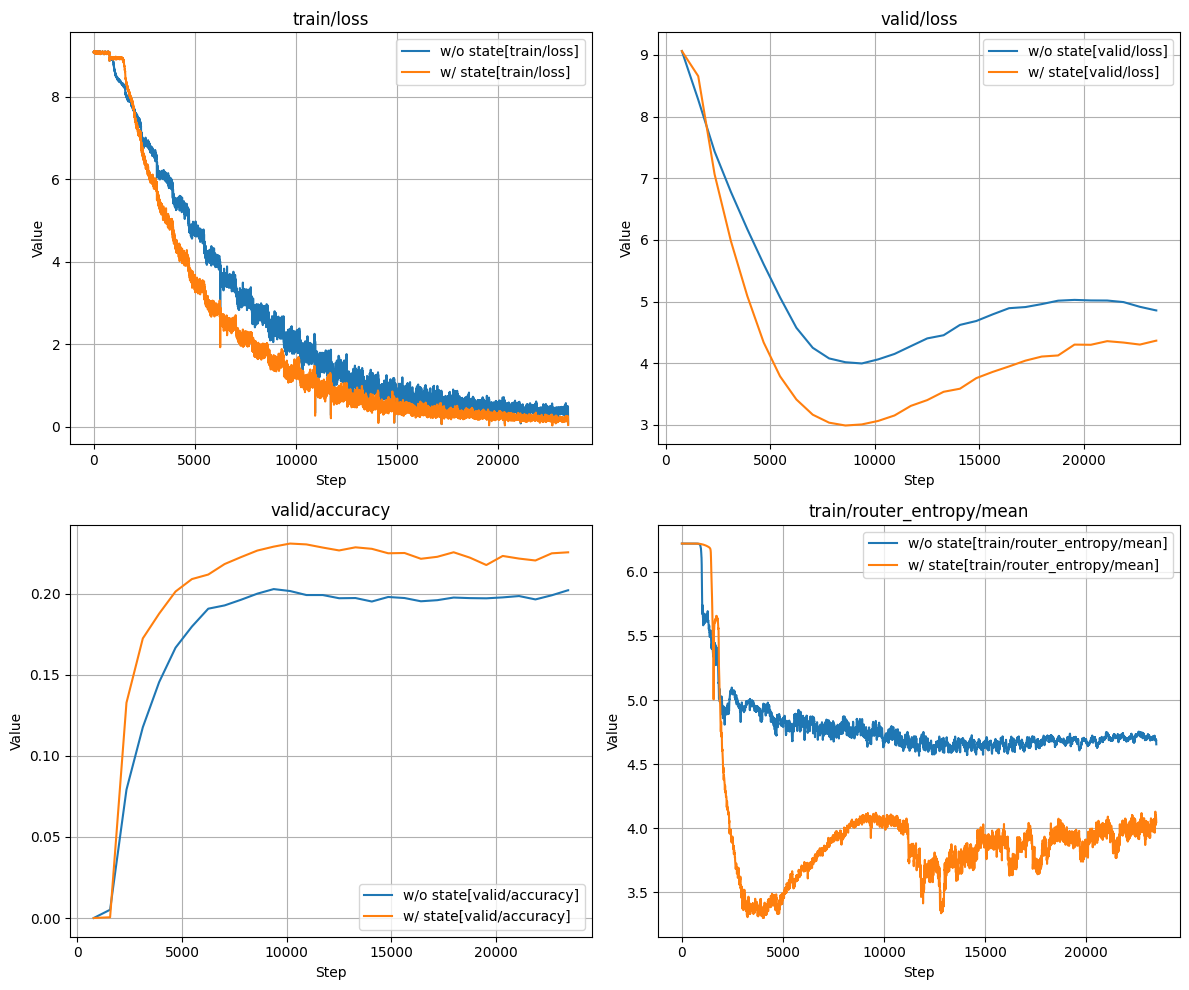

In [6]:
plot_metrics(
    {
        "w/o state": "/home/needpetrov/projects/zoology/runs/S4DMoEmini_256_D16_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778216647.butch.1022481.0",
        "w/ state": "/home/needpetrov/projects/zoology/runs/S4DMoEmini2_256_D16_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778218937.butch.1029913.0",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

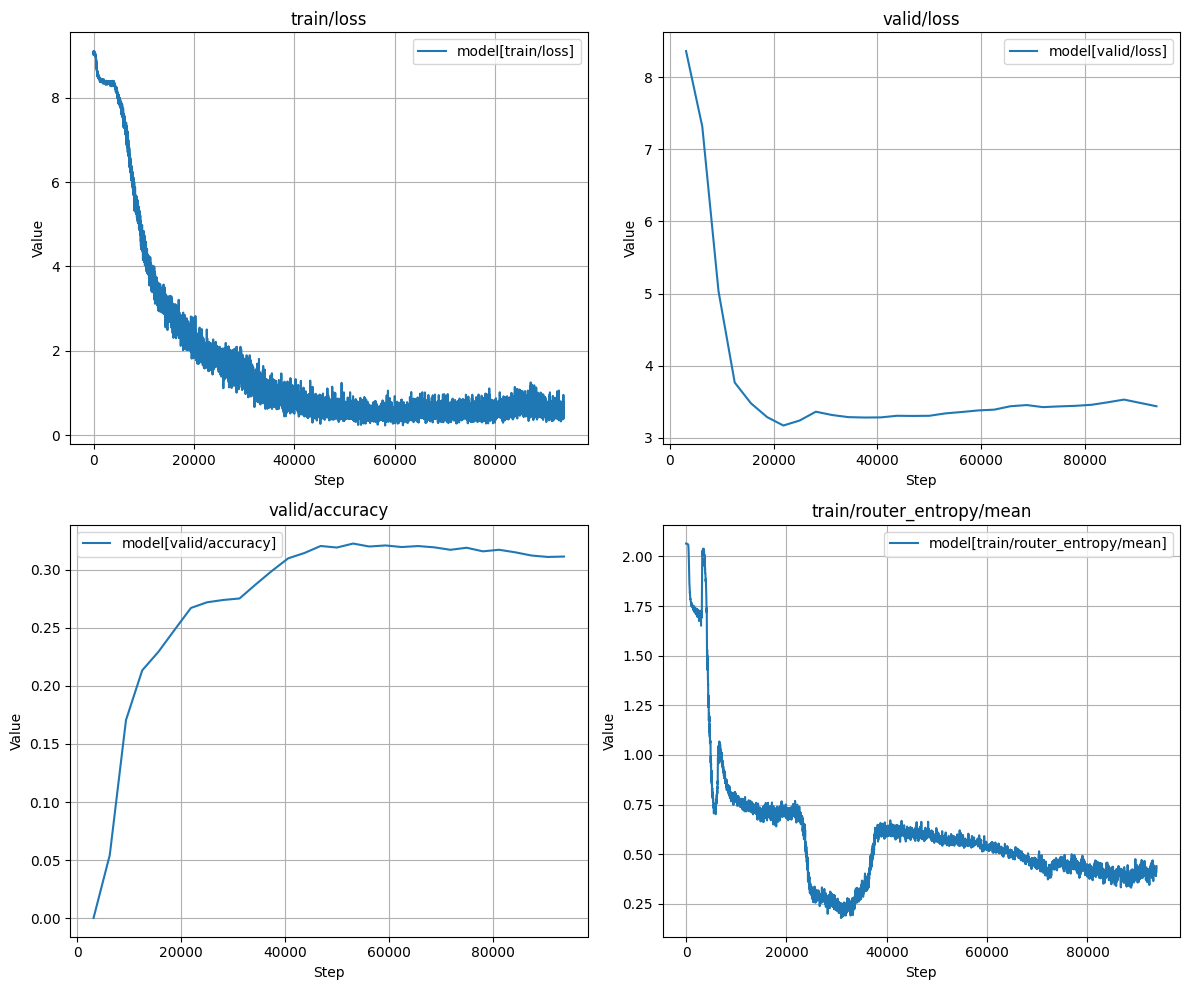

In [3]:
plot_metrics(
    {
        "model": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778323607.butch.1687238.0",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

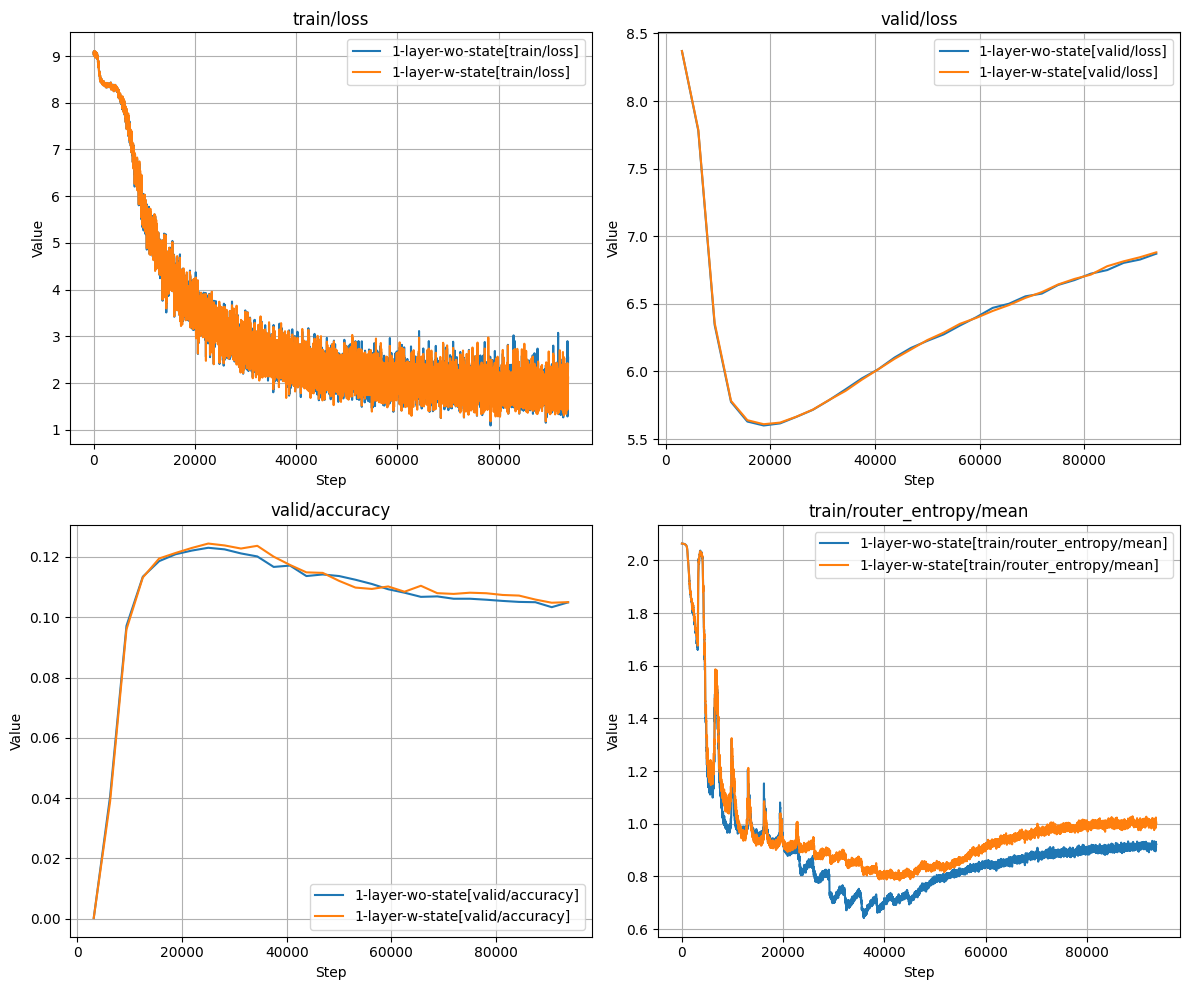

In [5]:
plot_metrics(
    {
        "1-layer-wo-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3_8A2_1_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778359822.butch.1874799.0",
        "1-layer-w-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3s_8A2_1_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778369721.butch.1874799.1"
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

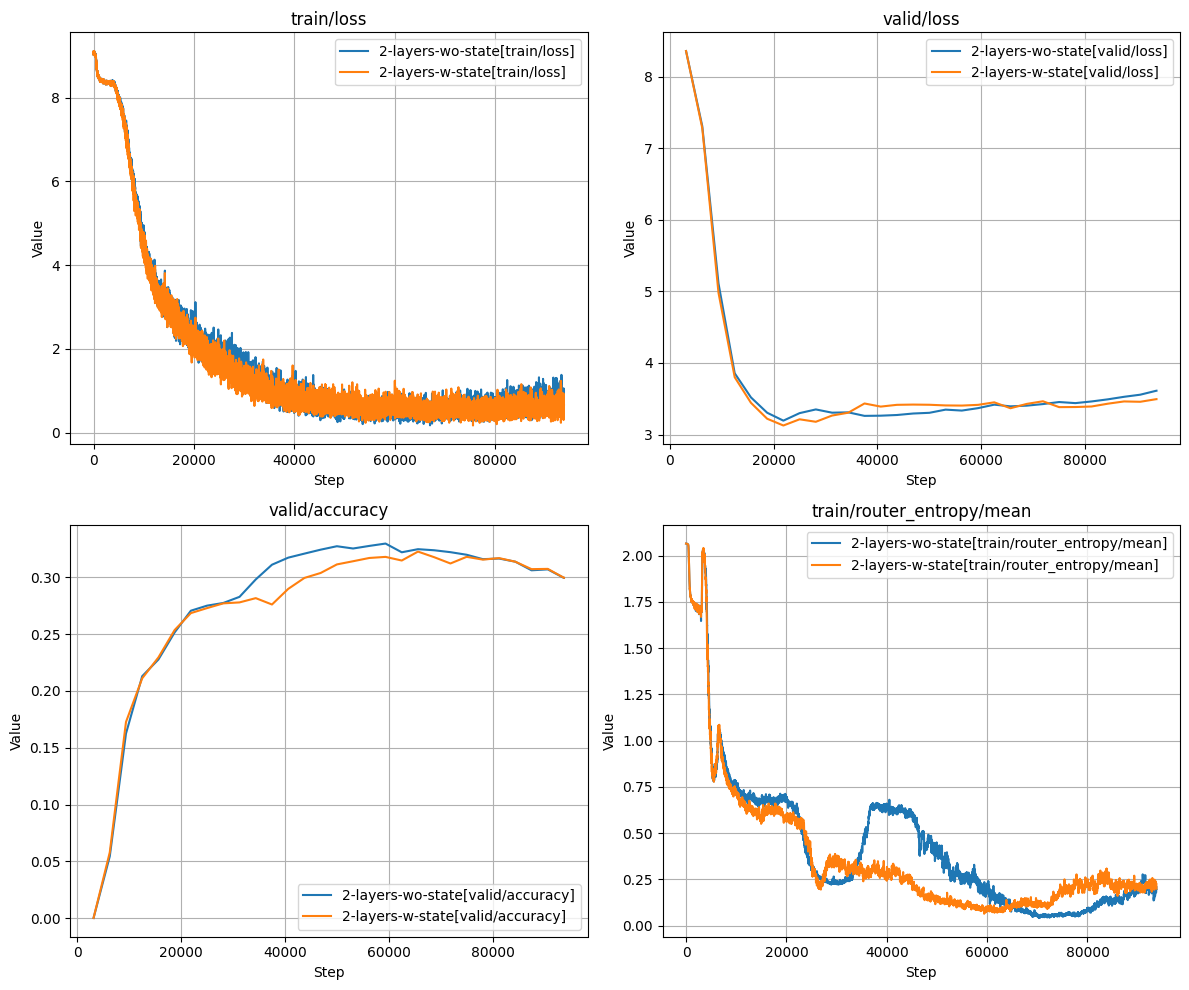

In [3]:
plot_metrics(
    {
        "2-layers-wo-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778359841.butch.1875088.0",
        "2-layers-w-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3s_8A2_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778377906.butch.1875088.1"
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

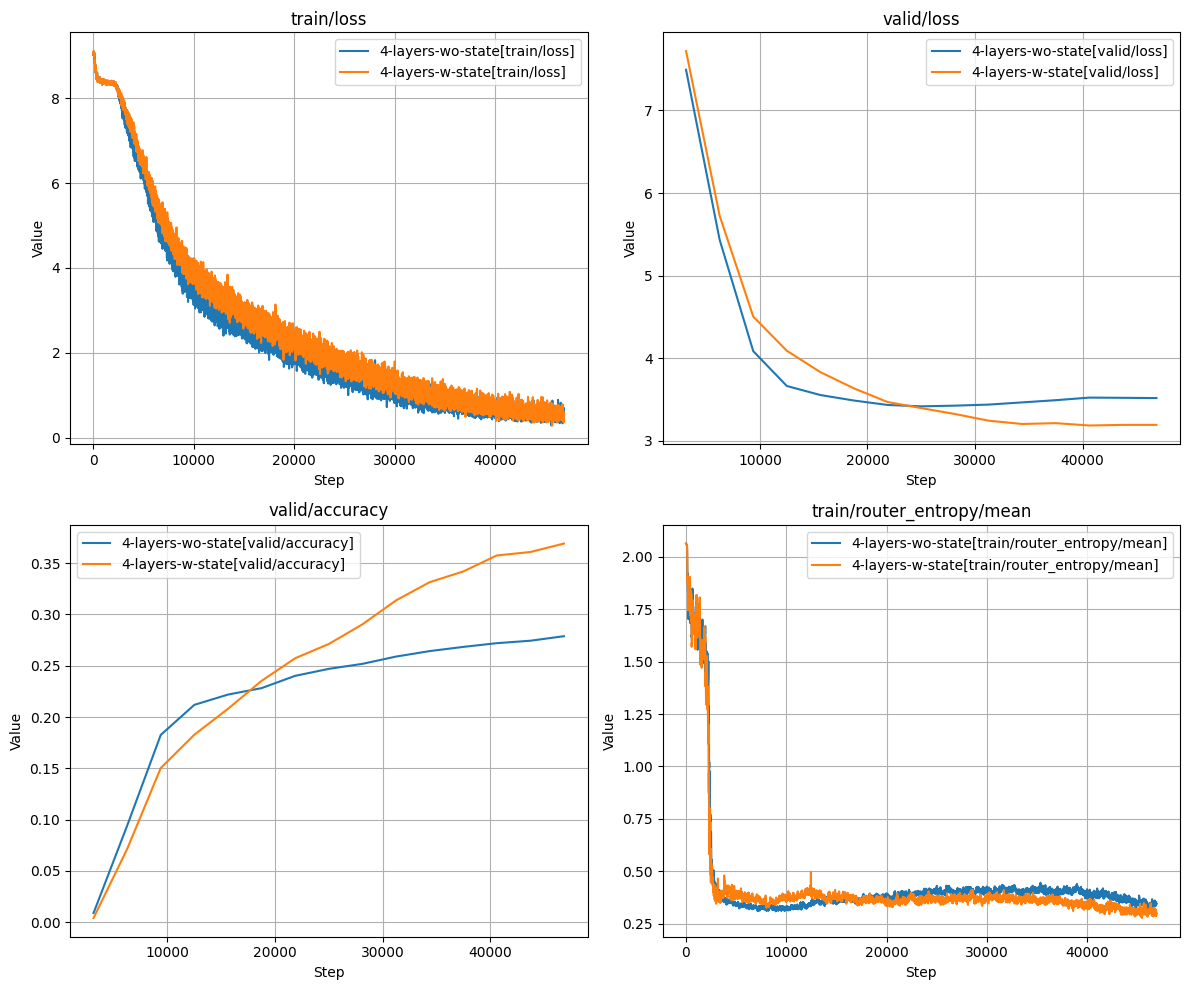

In [4]:
plot_metrics(
    {
        "4-layers-wo-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3_8A2_4_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778359918.butch.1875748.0",
        "4-layers-w-state": "/home/needpetrov/projects/zoology/runs/S4D_v3/model_v3s_8A2_4_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778377058.butch.1875748.1",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

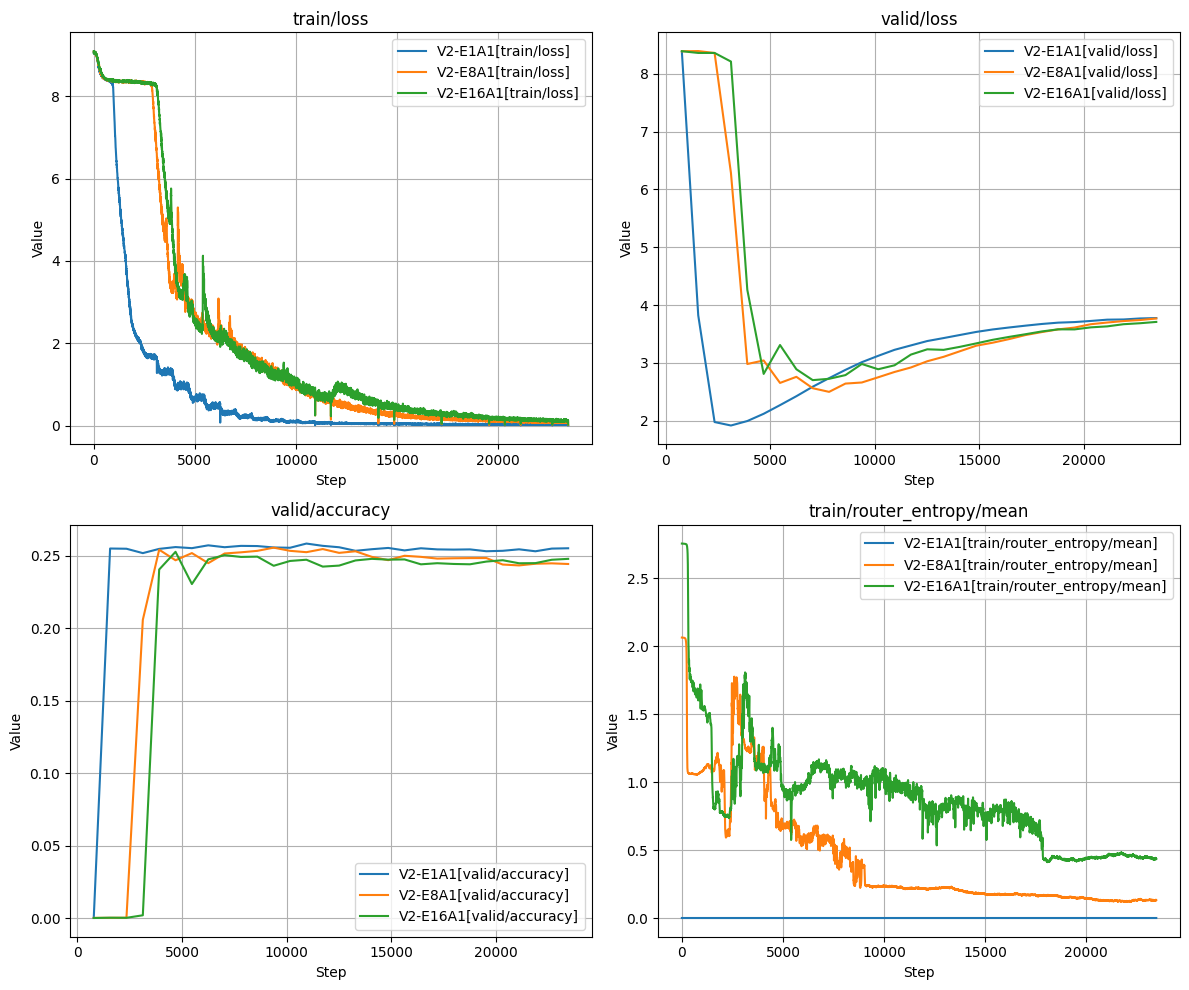

In [6]:
plot_metrics(
    {
        "V2-E1A1": "/home/needpetrov/projects/zoology/runs/S4D_v2/model_v2_E1_L2__lr_0.0003__difficulty_4/default/events.out.tfevents.1778363926.butch.1898211.0",
        "V2-E8A1": "/home/needpetrov/projects/zoology/runs/S4D_v2/model_v2_E8_L2__lr_0.0003__difficulty_4/default/events.out.tfevents.1778380630.butch.1898211.1",
        "V2-E16A1": "/home/needpetrov/projects/zoology/runs/S4D_v2/model_v2_E16_L2__lr_0.0003__difficulty_4/default/events.out.tfevents.1778393589.butch.1898211.2",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)

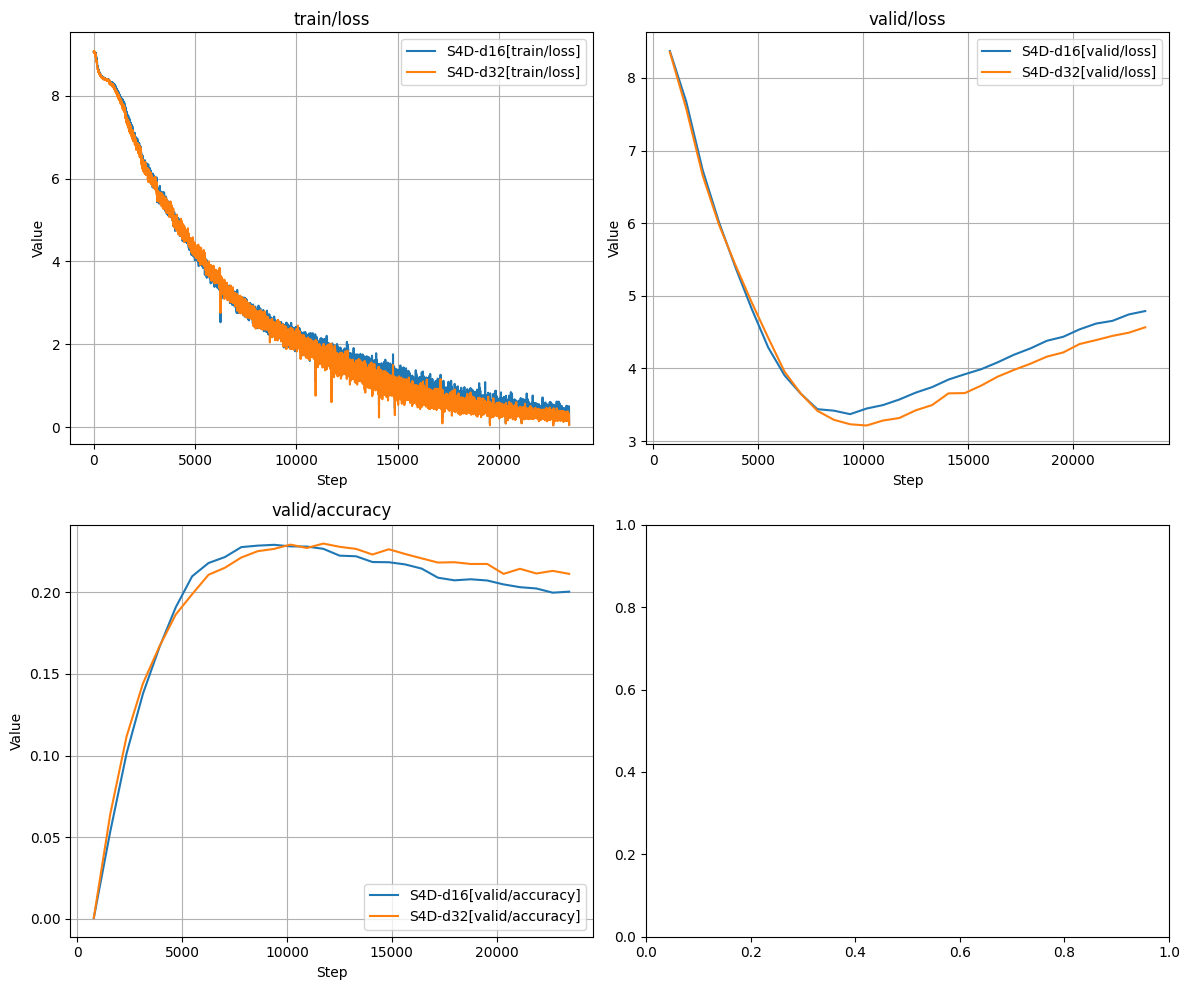

In [7]:
plot_metrics(
    {
        "S4D-d16": "/home/needpetrov/projects/zoology/runs/baselines_v1/S4D_256_D16_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778346170.butch.1843263.0",
        "S4D-d32": "/home/needpetrov/projects/zoology/runs/baselines_v1/S4D_256_D32_2_layers__lr_0.0003__difficulty_4/default/events.out.tfevents.1778348939.butch.1843263.1",
    },
    keys=["train/loss", "valid/loss", "valid/accuracy", "train/router_entropy/mean"],
    align_steps=False,
)